Check if repeatability is a good proxy for VI quality

In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
tt = Table.read('/global/cfs/cdirs/desi/users/rongpu/spectro/vi/truth_table_LRG_v1.2_tt.fits')
zbest = Table.read('/global/cfs/cdirs/desi/users/rongpu/spectro/vi/truth_table_LRG_v1.2_zbest_single_exp.fits')
print(len(tt), len(zbest))
print(np.all(tt['TARGETID']==zbest['TARGETID']))

1358 1358
True


In [4]:
# Remove stars (based on z)
mask = (tt['best z']<0.001) & (tt['best quality']>=2.5)
tt = tt[~mask]
zbest = zbest[~mask]
print(np.sum(mask), len(tt))

# SN_z cut
mask = zbest['sn_z']<0.5
tt = tt[~mask]
zbest = zbest[~mask]
print(np.sum(mask), len(tt))

# FIBER cut
mask = (zbest['FIBER']>2000) & (zbest['FIBER']<2500)
tt = tt[~mask]
zbest = zbest[~mask]
print(np.sum(mask), len(tt))

5 1353
12 1341
77 1264


In [5]:
sv0_lrg = zbest['CMX_TARGET'] & (2**10) > 0
print('SV0_LRG', np.sum(sv0_lrg))
mini_sv_lrg = zbest['CMX_TARGET'] & (2**53) > 0
print('MINI_SV_LRG', np.sum(mini_sv_lrg))

SV0_LRG 1264
MINI_SV_LRG 453


In [6]:
outlier_threshold = 0.0033

good_z = (tt['best quality']>=2.5) & np.abs(zbest['Z']-tt['best z']<=outlier_threshold)
# good_z = (tt['best quality']>=2.5)
print(np.sum(~good_z))

failures_per_object = np.zeros(len(zbest))
for index in range(len(zbest['Z_SUBSET'][0])):
    z_subset, z_truth = zbest['Z_SUBSET'][:, index], zbest['Z']
    failures_per_object += np.abs((z_subset - z_truth)) > outlier_threshold
not_repeatable = failures_per_object>0
print(np.sum(not_repeatable))

54
130


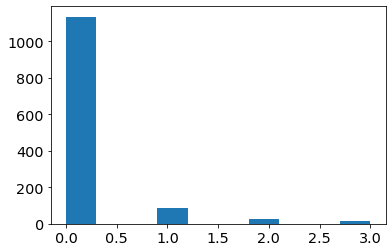

In [7]:
plt.hist(failures_per_object);

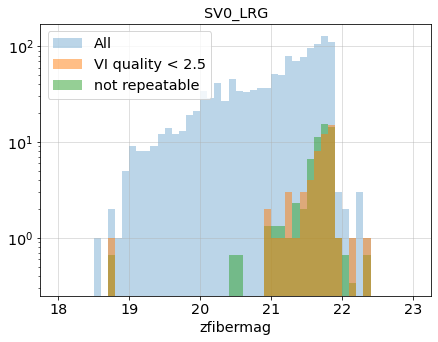

In [8]:
plt.figure(figsize=(7, 5))
plt.hist(zbest['zfibermag'], bins=50, alpha=0.3, range=(18, 23), label='All', zorder=1, log=True)
plt.hist(zbest['zfibermag'][~good_z], bins=50, alpha=0.5, range=(18, 23), label='VI quality < 2.5', zorder=3)
plt.hist(zbest['zfibermag'], weights=failures_per_object/len(zbest['Z_SUBSET'][0]), bins=50, alpha=0.5, range=(18, 23), label='not repeatable', zorder=2)
plt.xlabel('zfibermag')
plt.title('SV0_LRG')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

In [9]:
bad_but_repeatable = (~good_z) & (~not_repeatable)
print('not repeatable:', np.sum(not_repeatable), '  bad VI:', np.sum(~good_z))
print('bad but repeatable:', np.sum(bad_but_repeatable), np.sum(bad_but_repeatable)/np.sum(~good_z))

not repeatable: 130   bad VI: 54
bad but repeatable: 10 0.18518518518518517


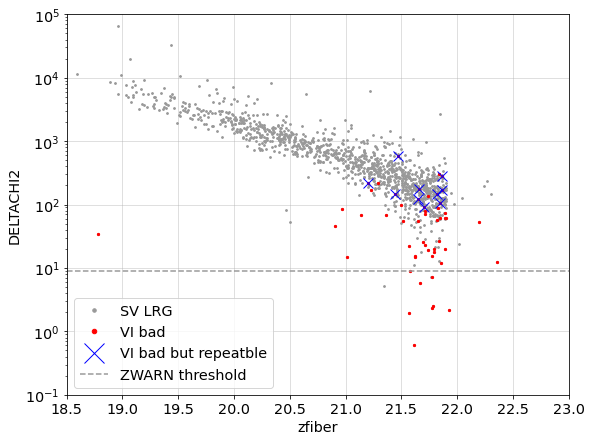

In [10]:
plt.figure(figsize=(9, 7))
plt.plot(zbest['zfibermag'], zbest['DELTACHI2'], '.', color='0.6', ms=3.5, alpha=1, label='SV LRG')
plt.plot(zbest['zfibermag'][~good_z], zbest['DELTACHI2'][~good_z], 'r.', ms=4.5, alpha=1, label='VI bad')
plt.plot(zbest['zfibermag'][bad_but_repeatable], zbest['DELTACHI2'][bad_but_repeatable], 'bx', ms=10, alpha=1, label='VI bad but repeatble')
plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('zfiber')
plt.ylabel('DELTACHI2')
plt.axis([18.5, 23., .1, 100000])
plt.legend(markerscale=2)
plt.grid(alpha=0.5)
plt.show()

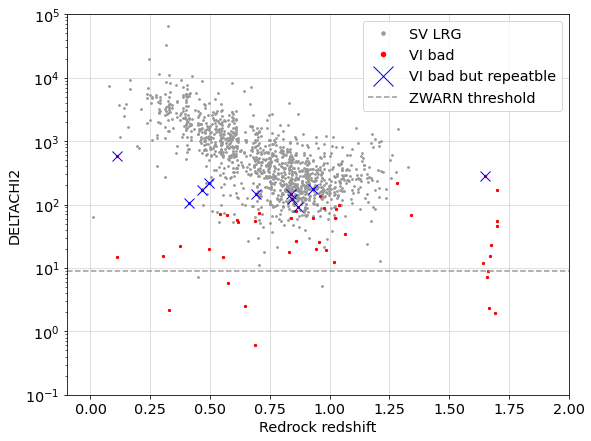

In [11]:
plt.figure(figsize=(9, 7))
plt.plot(zbest['Z'], zbest['DELTACHI2'], '.', color='0.6', ms=3.5, alpha=1, label='SV LRG')
plt.plot(zbest['Z'][~good_z], zbest['DELTACHI2'][~good_z], 'r.', ms=4.5, alpha=1, label='VI bad')
plt.plot(zbest['Z'][bad_but_repeatable], zbest['DELTACHI2'][bad_but_repeatable], 'bx', ms=10, alpha=1, label='VI bad but repeatble')
plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('Redrock redshift')
plt.ylabel('DELTACHI2')
plt.axis([-0.1, 2, .1, 100000])
plt.legend(markerscale=2)
plt.grid(alpha=0.5)
plt.show()

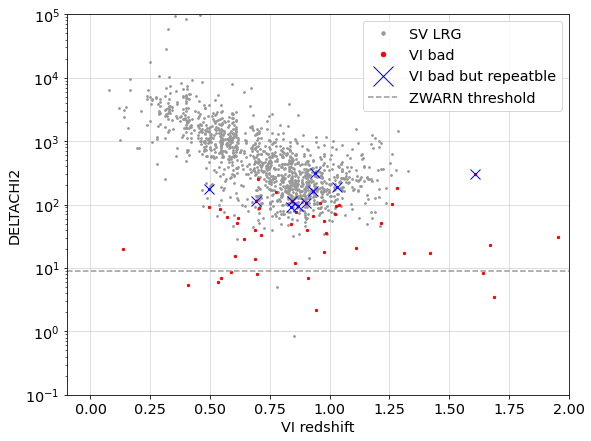

In [12]:
plt.figure(figsize=(9, 7))
plt.plot(tt['best z'], tt['DELTACHI2'], '.', color='0.6', ms=3.5, alpha=1, label='SV LRG')
plt.plot(tt['best z'][~good_z], tt['DELTACHI2'][~good_z], 'r.', ms=4.5, alpha=1, label='VI bad')
plt.plot(tt['best z'][bad_but_repeatable], tt['DELTACHI2'][bad_but_repeatable], 'bx', ms=10, alpha=1, label='VI bad but repeatble')
plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('VI redshift')
plt.ylabel('DELTACHI2')
plt.axis([-0.1, 2, .1, 100000])
plt.legend(markerscale=2)
plt.grid(alpha=0.5)
plt.show()

In [13]:
zbest[bad_but_repeatable]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,PMRA_IVAR,PMDEC_IVAR,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,NUMTARGET,PRIORITY,SUBPRIORITY,OBSCONDITIONS,NUMOBS_MORE,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,MORPHTYPE,TARGET_RA_IVAR,TARGET_DEC_IVAR,EBV,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,FRACFLUX_G,FRACFLUX_R,FRACFLUX_Z,FRACMASKED_G,FRACMASKED_R,FRACMASKED_Z,FRACIN_G,FRACIN_R,FRACIN_Z,NOBS_G,NOBS_R,NOBS_Z,PSFDEPTH_G,PSFDEPTH_R,PSFDEPTH_Z,GALDEPTH_G,GALDEPTH_R,GALDEPTH_Z,FLUX_W1,FLUX_W2,FLUX_W3,FLUX_W4,FLUX_IVAR_W1,FLUX_IVAR_W2,FLUX_IVAR_W3,FLUX_IVAR_W4,MW_TRANSMISSION_W1,MW_TRANSMISSION_W2,MW_TRANSMISSION_W3,MW_TRANSMISSION_W4,ALLMASK_G,ALLMASK_R,ALLMASK_Z,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,WISEMASK_W1,WISEMASK_W2,MASKBITS,FRACDEV,FRACDEV_IVAR,SHAPEDEV_R,SHAPEDEV_E1,SHAPEDEV_E2,SHAPEDEV_R_IVAR,SHAPEDEV_E1_IVAR,SHAPEDEV_E2_IVAR,SHAPEEXP_R,SHAPEEXP_E1,SHAPEEXP_E2,SHAPEEXP_R_IVAR,SHAPEEXP_E1_IVAR,SHAPEEXP_E2_IVAR,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_G_MEAN_FLUX_OVER_ERROR,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_BP_MEAN_FLUX_OVER_ERROR,GAIA_PHOT_RP_MEAN_MAG,GAIA_PHOT_RP_MEAN_FLUX_OVER_ERROR,GAIA_PHOT_BP_RP_EXCESS_FACTOR,GAIA_ASTROMETRIC_EXCESS_NOISE,GAIA_DUPLICATED_SOURCE,GAIA_ASTROMETRIC_SIGMA5D_MAX,GAIA_ASTROMETRIC_PARAMS_SOLVED,PARALLAX,PARALLAX_IVAR,PHOTSYS,CMX_TARGET,PRIORITY_INIT,NUMOBS_INIT,HPXPIXEL,BLOBDIST,FIBERFLUX_IVAR_G,FIBERFLUX_IVAR_R,FIBERFLUX_IVAR_Z,DESI_TARGET,BGS_TARGET,MWS_TARGET,NUM_ITER,FIBER_X,FIBER_Y,DELTA_X,DELTA_Y,FIBER_RA,FIBER_DEC,NIGHT,EXPID,MJD,TILEID,gmag,rmag,zmag,w1mag,w2mag,gfibermag,rfibermag,zfibermag,sn_g,sn_r,sn_z,CHI2_SUBSET [3],Z_SUBSET [3],ZERR_SUBSET [3],ZWARN_SUBSET [3],DELTACHI2_SUBSET [3],sn_g_SUBSET [3],sn_r_SUBSET [3],sn_z_SUBSET [3]
int64,float64,float64,float64,float64,int64,int64,bytes6,bytes20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,float32,float32,int64,uint8,bytes3,float32,float32,int16,int32,float64,int32,int64,int16,int32,bytes8,int32,bytes4,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,uint8,uint8,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int64,bytes2,float32,float32,float32,float32,float32,float32,float32,float32,bool,float32,bool,float32,float32,bytes1,int64,int64,int64,int64,float32,float32,float32,float32,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int32,int32,float64,int32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64
35185923939371730,9964.887790679932,313.886503707402 .. 48.03018440009048,1.6496237752178378,1.4679784434711496e-05,0,7927,GALAXY,,10,285.0275173187256,0,1,0,493,493,373,0,201.821321214919,6.74243282905199,0.0,0.0,0.0,0.0,0.0,5400.0,1024,1,TGT,44.50893,-380.82193,0,4000,0.544423435852281,65535,100,8000,369990,2017p067,2770,REX,5973838000.0,6109908000.0,0.028246693,0.1009254,0.8344832,4.31434,485.5836,117.07965,26.249134,0.9197844,0.94523185,0.96898556,0.71252006,0.1487512,0.05284749,0.010148183,0.013807872,0.011617326,0.9979203,0.99751186,0.99589616,2,2,2,1139.9547,271.9077,72.83534,708.741,169.11516,40.562122,15.8946,10.671905,-50.923298,-2874.7407,2.5820336,0.48196986,0.0010629086,1.4221245e-05,0.9952245,0.9970645,0.9993732,0.9997633,0,0,0,0.040842652,0.33769998,1.745934,

In [14]:
tt[bad_but_repeatable]

TARGETID,Redrock z,best z,best quality,Redrock spectype,best spectype,all VI issues,all VI comments,merger comment,N_VI,DELTACHI2,ZWARN,ZERR,FIBER,FLUX_G,FLUX_R,FLUX_Z,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,dz
int64,float64,float64,float64,bytes6,bytes6,bytes7,bytes262,bytes118,int64,float64,int64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
35185923939371730,1.6496,0.9396,2.0,GALAXY,GALAXY,RCS,Noisy spectra single narrow feature potentially sky subtraction Bad redshit fit; not a clear emission line detection as an indicative ; but it is a spectrum of a red galaxy Redrock wrong but actual redshift not clear,two different VI redshift offered with low mean confidence. take one with flag 2.,7,319.83968544006353,0,1.47159885718377e-05,373,0.10092539999999997,0.8344832,4.3143400000000005,0.040842652,0.33769998,1.745934,0.9197844000000001,0.94523185,0.96898556,0.36605485667147863
35185935930885982,0.467,1.0296,2.0,GALAXY,GALAXY,R,Based on OII Based on OII Used OII and H Balmer lines to determine the correct redshift,disagreement in flag and redshift. two VI z offered; taking the most convincing one with flag 2.,4,185.83090090751648,0,8.918967370777106e-06,890,0.13785663,0.6110576999999999,3.3120775,0.07212238,0.31968674,1.732778,0.9185665000000001,0.9443886,0.9685019,-0.2771974773354355
35185941928742082,0.4114,0.9014,1.6666666666666667,GALAXY,GALAXY,S,Redrock redshift not plausible likely a blend; I can't identify redshift Only from H-alpha and OIII the redshift determination could be likely,none,3,104.95627999305724,0,2.379684247670014e-05,784,0.3361366,0.9669956,3.2842307,0.18170972,0.5227413,1.7753991999999998,0.9320510000000001,0.9537051,0.97383463,-0.2577048490585884
35185941958100977,0.8406,0.8406,2.0,GALAXY,GALAXY,--,--,disagreement in flag. z not secure; set to 2.,3,92.03697534650564,0,6.54692452005711e-05,4181,0.12120732,0.6618241,4.1761610000000005,0.052370764000000014,0.28595826,1.8044184,0.9121981,0.9399732,0.96596646,0.0
35185947947569050,0.8672,0.8672,2.0,GALAXY,GALAXY,--,--,mismatch in flag. z not secure; set to 2.,3,96.36835733056068,0,0.00013436762725990082,4109,0.08610704,0.7585963000000001,3.6027362000000003,0.048159745,0.4242835999999999,2.0150137,0.92255986,0.94715226,0.9700861999999999,0.0
35185959892945291,0.9286,0.9286,2.333333333333333,GALAXY,GALAXY,--,spectype is secure; no >1 clean alignment for secure redshift alignment,none,3,164.72978377342224,0,8.460545552583376e-05,1597,0.045675263,0.6634759,4.611657599999999,0.021008933,0.30517438,2.121192,0.93813425,0.9578936,0.9762245999999999,0.0
35185965894995908,0.4964,0.4964,2.0,GALAXY,GALAXY,--,5570 AA sky residual degenerate with [OII] --,flag disagreement; z not secure.,3,178.0249972715974,0,6.24765328457333e-05,3507,0.53306425,2.8284867,8.127991999999999,0.21101071,1.1196418,3.2174232000000003,0.9283457,0.95114946,0.9723741,0.0
35185971867685808,0.8424,0.8424,2.0,GALAXY,GALAXY,--,--,flag disagreement; z not reliable,3,112.0440357849002,0,0.00012056368381108328,2825,0.110147454,0.5950554,3.1204767,0.07535794400000001,0.4071102,2.13489,0.9370016,0.9571144,0.97578037,0.0
35185971884461099,0.6907,0.6907,2.0,GALAXY,GALAXY,--,--,disagreement in flag. all major lines in noise spikes; no clear features. set to 2.,3,113.0305073224008,0,6.463618499860142e-05,3904,0.36097416,1.3782241000000002,4.9674907,0.1866287,0.7125611999999999,2.5682623,0.9266970999999999,0.9500113000000001,0.9717231,0.0


In [15]:
4.5/0.5

9.0

(array([0., 0., 0., 1., 8., 1., 0., 0., 0.]),
 array([-0.25,  0.25,  0.75,  1.25,  1.75,  2.25,  2.75,  3.25,  3.75,
         4.25]),
 <a list of 9 Patch objects>)

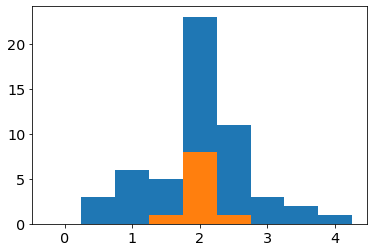

In [16]:
plt.hist(tt['best quality'][(~good_z)], range=(-0.25, 4.25), bins=9)
plt.hist(tt['best quality'][(bad_but_repeatable)], range=(-0.25, 4.25), bins=9)

In [17]:
tt[(~good_z) & (~bad_but_repeatable)]

TARGETID,Redrock z,best z,best quality,Redrock spectype,best spectype,all VI issues,all VI comments,merger comment,N_VI,DELTACHI2,ZWARN,ZERR,FIBER,FLUX_G,FLUX_R,FLUX_Z,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,dz
int64,float64,float64,float64,bytes6,bytes6,bytes7,bytes262,bytes118,int64,float64,int64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
35185923939371905,1.0205,2.428571,2.4285710000000003,GALAXY,GALAXY,RCS,Noisy spectra many weak features fit to HK; possible issue with continuum in the blue arm Redshift from Redrock believed becasue of OII,disagreement in flag and z. take redrock z with mean flag.,7,14.975785337388515,0,0.00010079158848608158,358,0.27443233,0.7441555000000001,6.3345,0.047814954000000014,0.12965587,1.103674,0.9175235,0.94366616,0.96808743,-0.41068742633592825
35185923939373860,1.6997,1.2130199999999998,3.0,GALAXY,QSO,RC,Noisy spectra weak noisy but potentially some broad features QSO? Bad redshift fit; CIV line is the only clear indication; there is a broaden emission at 9500-9700AA not acknowledged by the model Very confusing QSO with incorrect template fit.,5/7 inspectors suggest same VI redshift.QSO missed by RR.,7,50.69547288119793,32,0.00017982062852635886,396,0.8871611999999999,2.4107678,5.850298,0.6380954000000001,1.7339574,4.2078576,0.9159219999999999,0.94255626,0.9674504,0.2199166749509721
35185923943564344,0.802,1.4193,2.0,QSO,GALAXY,R2S14.C,possible oii doublet at high-z bad sky at 5577 QSO not correct template - redshift based on OIII ONLY so insecure,2/7 inspectors suggest same VI z; flag 2. not a QSO.,7,16.923035223037008,0,0.00019689184185012838,496,0.391495,1.8281147,5.879105,0.15147482,0.70732284,2.2747068,0.9166284,0.9430459000000001,0.9677314,-0.2551564502128715
35185929937224636,1.0286,1.0286,1.0,QSO,QSO,C,lots of signal; but I can't identify object Redshift based on OII only,disagreement in z; flag and spectype with low confidence. take rr solution; flag 1.,4,94.742808226496,0,0.0001293103155009718,519,0.96133554,1.8681531,5.923271,0.6450108,1.2534426,3.9742358,0.9208488000000001,0.9459685,0.96940786,0.0
35185929954005641,0.6887,0.6887,2.333333333333333,GALAXY,GALAXY,--,Post-starburst --,none,3,39.162173319607966,0,8.85525913140252e-05,4788,-0.0022266884,0.77422684,3.753333,0.0,0.49185035,2.3844151,0.91005826,0.93848723,0.96511203,0.0
35185929954005881,0.69,0.69,2.0,GALAXY,GALAXY,--,Post-starburst Ca-K is missed by the model --,one inspector forgot to set a flag. set to mean of other two.,3,13.704152017831802,0,7.499192864442326e-05,4796,0.23289888,0.75849897,3.9135914,0.12971285,0.42244542,2.1796717999999995,0.9114825999999999,0.93947643,0.96568084,0.0
35185935926691293,1.0215,1.0215,2.0,GALAXY,GALAXY,--,Post-starburst Post-starburst --,disagreement in flag. z not secure; set to 2.,4,72.16598965227605,0,0.00015587964811930206,568,0.050810207,0.45692852,2.9675574,0.030357843,0.27300352,1.7730422,0.92574453,0.9493534,0.9713466000000001,0.0
35185935939274709,0.616,0.616,2.333333333333333,GALAXY,GALAXY,--,--,none,3,60.368393019773066,0,0.00011009847402553145,37,0.8728121999999999,2.6094134,7.639603599999999,0.14654092,0.43810782,1.2826523,0.9136447,0.9409770000000001,0.9665433000000001,0.0
35185935951859235,0.9319,0.9319,2.333333333333333,GALAXY,GALAXY,--,--,none,3,65.64903617370875,0,0.0003340265237575976,4989,0.047403038,0.40104204,2.5640876,0.031509373,0.26657748,1.70438,0.92084515,0.945966,0.9694064,0.0
